# Convolutional Neural Network - Fruit Classification

#### Import required packages

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

## Set Up flow For Training & Validation data

#### data flow parameters

In [2]:
training_data_dir = 'data/training'
validation_data_dir = 'data/validation'
batch_size = 32
img_width = 128
img_height = 128
num_channels = 3
num_classes = 6

#### image generators

In [5]:
training_generator = ImageDataGenerator(rescale = 1./255,
                                       rotation_range = 20,
                                       width_shift_range = 0.2,
                                       height_shift_range = 0.2,
                                       zoom_range = 0.1,
                                       horizontal_flip = True,
                                       brightness_range = (0.5,1.5),
                                       fill_mode = 'nearest')

validation_generator = ImageDataGenerator(rescale = 1./255)

#### image flows

In [6]:
training_set = training_generator.flow_from_directory(directory = training_data_dir,
                                                     target_size = (img_width, img_height),
                                                     batch_size = batch_size,
                                                     class_mode = 'categorical')

validation_set = validation_generator.flow_from_directory(directory = validation_data_dir,
                                                         target_size = (img_width, img_height),
                                                         batch_size = batch_size,
                                                         class_mode = 'categorical')

Found 360 images belonging to 6 classes.
Found 180 images belonging to 6 classes.


## Network Architecture

#### network architecture

In [7]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', input_shape = (img_width, img_height, num_channels)))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'same'))
model.add(Activation('relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(32))
model.add(Activation('relu'))
# model.add(Dropout(0.5))

model.add(Dense(num_classes))
model.add(Activation('softmax'))

/opt/anaconda3/envs/dsi-deep-learning/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### compile network

In [8]:
model.compile(loss = 'categorical_crossentropy',
             optimizer = 'adam',
             metrics = ['accuracy'])

#### view network architecture

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     1,048,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,950 (4.04 MB)

 Trainable params: 1,058,950 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

## Train Our Network

#### training parameters

In [10]:
num_epochs = 50
model_filename = 'models/fruits_cnn_v03.h5'

#### callbacks

In [11]:
save_best_model = ModelCheckpoint(filepath = model_filename,
                                 monitor = 'val_accuracy',
                                 mode = 'max',
                                 verbose = 1,
                                 save_best_only = True)

#### train the network

In [12]:
history = model.fit(x = training_set,
                   validation_data = validation_set,
                   batch_size = batch_size,
                   epochs = num_epochs,
                   callbacks = [save_best_model])

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1979 - loss: 2.5738
Epoch 1: val_accuracy improved from None to 0.16667, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.1833 - loss: 2.2614 - val_accuracy: 0.1667 - val_loss: 1.7767
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1650 - loss: 1.7794
Epoch 2: val_accuracy improved from 0.16667 to 0.28889, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.1806 - loss: 1.7753 - val_accuracy: 0.2889 - val_loss: 1.6819
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3504 - loss: 1.7000
Epoch 3: val_accuracy improved from 0.28889 to 0.33333, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.3472 - loss: 1.6831 - val_accuracy: 0.3333 - val_loss: 1.5462
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3873 - loss: 1.5687
Epoch 4: val_accuracy improved from 0.33333 to 0.55000, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4694 - loss: 1.5344 - val_accuracy: 0.5500 - val_loss: 1.3390
Epoch 5/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5503 - loss: 1.3979
Epoch 5: val_accuracy did not improve from 0.55000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5167 - loss: 1.3509 - val_accuracy: 0.5444 - val_loss: 1.1315
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5022 - loss: 1.2756
Epoch 6: val_accuracy improved from 0.55000 to 0.72778, saving model to models/fruits_cnn_v03.h5


...

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8472 - loss: 0.4249 - val_accuracy: 0.9333 - val_loss: 0.2280
Epoch 21/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8864 - loss: 0.3269
Epoch 21: val_accuracy did not improve from 0.93333
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8944 - loss: 0.3480 - val_accuracy: 0.8944 - val_loss: 0.2595
Epoch 22/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8908 - loss: 0.3117
Epoch 22: val_accuracy improved from 0.93333 to 0.93889, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8806 - loss: 0.3238 - val_accuracy: 0.9389 - val_loss: 0.1985
Epoch 23/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9012 - loss: 0.3381
Epoch 23: val_accuracy did not improve from 0.93889
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8917 - loss: 0.3497 - val_accuracy: 0.9167 - val_loss: 0.2296
Epoch 24/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9288 - loss: 0.3364
Epoch 24: val_accuracy did not improve from 0.93889
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.8944 - loss: 0.3821 - val_accuracy: 0.9000 - val_loss: 0.2635
Epoch 25/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8783 - loss: 0.3354
Epoch 25: val_accuracy improved from 0.93889 to 0.95000, saving model to models/fruits_cnn_v03.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9056 - loss: 0.3167 - val_accuracy: 0.9500 - val_loss: 0.1859
Epoch 26/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8973 - loss: 0.3175
Epoch 26: val_accuracy did not improve from 0.95000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9250 - loss: 0.2622 - val_accuracy: 0.9333 - val_loss: 0.1951
Epoch 27/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9309 - loss: 0.2116
Epoch 27: val_accuracy did not improve from 0.95000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9278 - loss: 0.2453 - val_accuracy: 0.9111 - val_loss: 0.2132
Epoch 28/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9210 - loss: 0.2224
Epoch 28: val_accuracy did not improve from 0.95000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9167 - loss: 0.2418 - val_accuracy: 0.9333 - val_loss: 0.2479
Epoch 29/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9205 - loss: 0.3314
Epoch 29: val_accuracy did not impro

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9417 - loss: 0.2023 - val_accuracy: 0.9556 - val_loss: 0.1608
Epoch 41/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9519 - loss: 0.1614
Epoch 41: val_accuracy did not improve from 0.95556
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9444 - loss: 0.1725 - val_accuracy: 0.9111 - val_loss: 0.2369
Epoch 42/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9355 - loss: 0.1892
Epoch 42: val_accuracy did not improve from 0.95556
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9444 - loss: 0.1807 - val_accuracy: 0.9444 - val_loss: 0.1438
Epoch 43/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9540 - loss: 0.1225
Epoch 43: val_accuracy did not improve from 0.95556
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9389 - loss: 0.1788 - val_accuracy: 0.9389 - val_loss: 0.1863
Epoch 44/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9520 - loss: 0.1736
Epoch 44: val_accuracy did not impro

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9306 - loss: 0.1931 - val_accuracy: 0.9611 - val_loss: 0.1605
Epoch 48/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8874 - loss: 0.2615
Epoch 48: val_accuracy did not improve from 0.96111
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8778 - loss: 0.3144 - val_accuracy: 0.8167 - val_loss: 0.4518
Epoch 49/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8763 - loss: 0.3742
Epoch 49: val_accuracy did not improve from 0.96111
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9111 - loss: 0.2949 - val_accuracy: 0.9056 - val_loss: 0.2268
Epoch 50/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9361 - loss: 0.1910
Epoch 50: val_accuracy did not improve from 0.96111
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9389 - loss: 0.1982 - val_accuracy: 0.8722 - val_loss: 0.2610


## Visualise Training & Validation Performance

In [13]:
import matplotlib.pyplot as plt

#### plot validation results

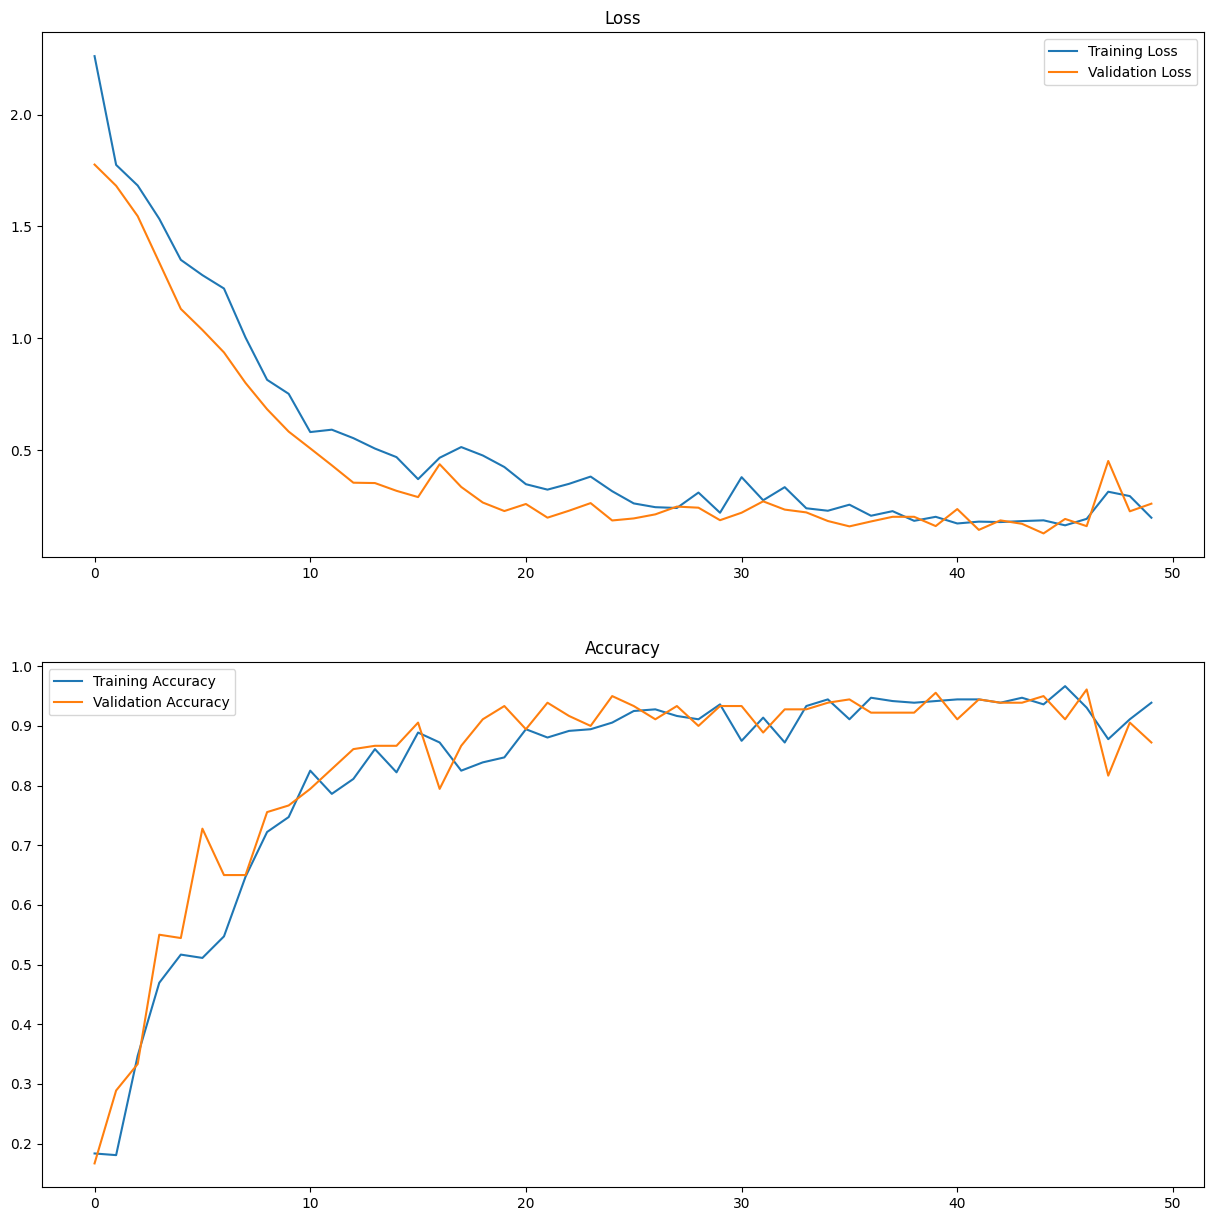

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(15,15))
ax[0].set_title('Loss')
ax[0].plot(history.epoch, history.history["loss"], label="Training Loss")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation Loss")
ax[1].set_title('Accuracy')
ax[1].plot(history.epoch, history.history["accuracy"], label="Training Accuracy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Accuracy")
ax[0].legend()
ax[1].legend()
plt.show()

#### get best epoch performance for validation accuracy

In [15]:
max(history.history['val_accuracy'])

0.9611111283302307

## Make Predictions On New Data (Test Set)

#### import required packages

In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import pandas as pd
from os import listdir

#### parameters for prediction

In [17]:
model_filename = 'models/fruits_cnn_v03.h5'
img_width = 128
img_height = 128
labels_list = ['apple', 'avocado', 'banana', 'kiwi', 'lemon', 'orange']

#### load model

In [18]:
model = load_model(model_filename)

#### image pre-processing function

In [19]:
def preprocess_image(filepath):

    image = load_img(filepath, target_size = (img_width, img_height))
    image = img_to_array(image)
    image = np.expand_dims(image, axis = 0)
    image = image * (1./255)

    return image

#### image prediction function

In [20]:
def make_prediction(image):

    class_probs = model.predict(image)
    predicted_class = np.argmax(class_probs)
    predicted_label = labels_list[predicted_class]
    predicted_prob = class_probs[0][predicted_class]

    return predicted_label, predicted_prob

#### loop through test data

In [21]:
source_dir = 'data/test/'
folder_names = ['apple', 'avocado', 'banana', 'kiwi', 'lemon', 'orange']
actual_labels = []
predicted_labels = []
predicted_probabilities = []
filenames = []

for folder in folder_names:

    images = listdir(source_dir + '/' + folder)

    for image in images:

        processed_image = preprocess_image(source_dir + '/' + folder + '/' + image)
        predicted_label, predicted_probability = make_prediction(processed_image)

        actual_labels.append(folder)
        predicted_labels.append(predicted_label)
        predicted_probabilities.append(predicted_probability)
        filenames.append(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

#### create dataframe to analyse

In [22]:
predictions_df = pd.DataFrame({"actual_label" : actual_labels,
                              "predicted_label" : predicted_labels,
                              "predicted_probability" : predicted_probabilities,
                              "filename" : filenames})

predictions_df['correct'] = np.where(predictions_df['actual_label'] == predictions_df['predicted_label'], 1, 0)

#### overall test set accuracy

In [23]:
test_set_accuracy = predictions_df['correct'].sum() / len(predictions_df)
print(test_set_accuracy)

1.0


#### confusion matrix (raw numbers)

In [24]:
confusion_matrix = pd.crosstab(predictions_df['predicted_label'], predictions_df['actual_label'])
print(confusion_matrix)

actual_label     apple  avocado  banana  kiwi  lemon  orange
predicted_label                                             
apple               10        0       0     0      0       0
avocado              0       10       0     0      0       0
banana               0        0      10     0      0       0
kiwi                 0        0       0    10      0       0
lemon                0        0       0     0     10       0
orange               0        0       0     0      0      10


#### confusion matrix (percentages)

In [25]:
confusion_matrix = pd.crosstab(predictions_df['predicted_label'], predictions_df['actual_label'], normalize = 'columns')
print(confusion_matrix)

actual_label     apple  avocado  banana  kiwi  lemon  orange
predicted_label                                             
apple              1.0      0.0     0.0   0.0    0.0     0.0
avocado            0.0      1.0     0.0   0.0    0.0     0.0
banana             0.0      0.0     1.0   0.0    0.0     0.0
kiwi               0.0      0.0     0.0   1.0    0.0     0.0
lemon              0.0      0.0     0.0   0.0    1.0     0.0
orange             0.0      0.0     0.0   0.0    0.0     1.0
